<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_04_Modeling_a_Moving_Average_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Modeling a Moving Average Process

*Companion notebook to* **Time Series Forecasting in Python** *by Marco Peixeiro (Manning, 2022) — Chapter 4.*

## Chapter overview

In Chapter 3 we identified the **random walk** as the simplest non-stationary process: a series whose first difference is white noise with zero autocorrelation. But what happens when the first difference *is* stationary yet still shows autocorrelation? Such a series cannot be a random walk — it is generated by a more structured process. One of the simplest such structures is the **moving average process** $\text{MA}(q)$, where the current value depends linearly on the current and past error terms:

$$y_t \;=\; \mu \;+\; \varepsilon_t \;+\; \theta_1 \varepsilon_{t-1} \;+\; \theta_2 \varepsilon_{t-2} \;+\; \cdots \;+\; \theta_q \varepsilon_{t-q}$$

In this chapter we will:

1. Define the **moving average process** $\text{MA}(q)$ formally and intuitively.
2. Identify the **order** $q$ of an MA process from its **autocorrelation function (ACF)**.
3. Build a **rolling forecast** for the volume of widget sales at the XYZ Widget Company, comparing an $\text{MA}(2)$ model against two naive baselines.
4. **Inverse-transform** the differenced forecasts back to the original scale and report a business-meaningful error metric.

We close with two simulation exercises that consolidate the workflow on synthetic $\text{MA}(2)$ and $\text{MA}(3)$ processes.

## Setup

We use `statsmodels` for hypothesis testing (`adfuller`), ACF plotting, and the `SARIMAX` state-space model (which subsumes pure MA models as the special case $\text{ARIMA}(0,0,q)$). `scikit-learn` provides the error metrics, and `numpy`/`pandas`/`matplotlib` handle the rest. The `widget_sales.csv` file is fetched directly from the book's GitHub repository, so this notebook runs end-to-end on Google Colab without any local file uploads.

In [1]:
# Install packages (Colab usually has these; the -q keeps output quiet)
!pip install -q statsmodels scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print('numpy       :', np.__version__)
print('pandas      :', pd.__version__)
print('matplotlib  :', __import__('matplotlib').__version__)
print('statsmodels :', __import__('statsmodels').__version__)

numpy       : 2.0.2
pandas      : 2.2.2
matplotlib  : 3.10.0
statsmodels : 0.14.6


All imports succeed. We use `warnings.filterwarnings('ignore')` to suppress the many `ConvergenceWarning` and `FutureWarning` messages that `statsmodels` emits when fitting state-space models — these warnings are informational and do not affect parameter estimates.

## 4.1 Defining a moving average process

A **moving average process** of order $q$, written $\text{MA}(q)$, expresses the current value as a linear combination of the series mean $\mu$, the current shock $\varepsilon_t$, and the $q$ most recent past shocks:

$$y_t \;=\; \mu \;+\; \varepsilon_t \;+\; \theta_1 \varepsilon_{t-1} \;+\; \theta_2 \varepsilon_{t-2} \;+\; \cdots \;+\; \theta_q \varepsilon_{t-q}$$

The shocks $\{\varepsilon_t\}$ are assumed **i.i.d.** with $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ — exactly the white-noise assumption from Chapter 3. The coefficients $\theta_1, \theta_2, \ldots, \theta_q$ are the **MA parameters** that the model must estimate from data.

**Two special cases worth memorising:**

$$
\underbrace{y_t \;=\; \mu \;+\; \varepsilon_t \;+\; \theta_1 \varepsilon_{t-1}}_{\text{MA}(1)}
\qquad\qquad
\underbrace{y_t \;=\; \mu \;+\; \varepsilon_t \;+\; \theta_1 \varepsilon_{t-1} \;+\; \theta_2 \varepsilon_{t-2}}_{\text{MA}(2)}
$$

**Intuition.** Think of $\varepsilon_t$ as today's surprise (the part of $y_t$ that no past data could have predicted). An $\text{MA}(q)$ process says: *today's value is the long-run mean, plus today's surprise, plus an echo of the last $q$ surprises that fades after $q$ steps.* This is fundamentally different from an autoregressive process, where the **value** itself (not the surprise) propagates forward.

**Key consequence.** Because the influence of any past shock disappears after exactly $q$ lags, the **autocorrelation function vanishes for lags $> q$**. This sharp cutoff is the signature we will use to identify $q$ from data.

### 4.1.1 Identifying the order of a moving average process

The identification recipe extends the random-walk procedure from Chapter 3:

1. **Gather** the data.
2. Test for **stationarity** (ADF). If non-stationary, **difference** until stationary.
3. Plot the **ACF** of the stationary series.
4. If autocorrelation coefficients are significant up to lag $q$ and **abruptly** drop into the non-significance band thereafter, we have an $\text{MA}(q)$ process.

We now apply this recipe to XYZ Widget Company's 500-day sales series.

In [2]:
# Load the dataset directly from the book's GitHub mirror
URL = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/widget_sales.csv'
df = pd.read_csv(URL)

print('Shape:', df.shape)
df.head()

Shape: (500, 1)


,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


The dataset contains $500$ daily observations of `widget_sales`, denominated in thousands of US dollars (k\$). The first five values hover around \$50k–\$55k. The single column means we are dealing with a **univariate** time series — a setting where classical models like $\text{MA}(q)$, $\text{AR}(p)$ and $\text{ARIMA}$ are designed to shine.

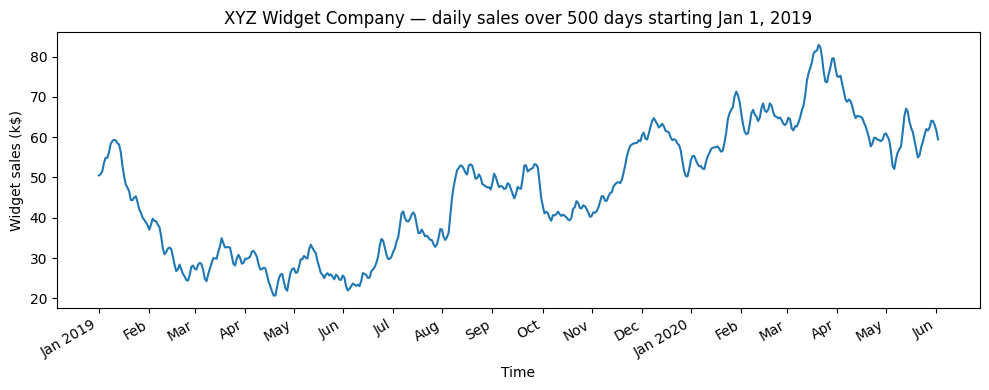

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')
ax.set_title('XYZ Widget Company — daily sales over 500 days starting Jan 1, 2019')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
     'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The raw series shows a clear **upward drift** from roughly $\$50$k at the start of 2019 to peaks near $\$70$k in mid-2020, with substantial peak-and-trough oscillations along the way. Two visual cues already suggest non-stationarity:

- The **mean is time-varying** — the average over the first 100 days is well below the average over the last 100 days.
- The **variance** appears wider in the second half (larger swings).

There is no obvious repeating cycle, so we can provisionally rule out seasonality. The drift alone is enough to disqualify the series as stationary — but we confirm formally with the **Augmented Dickey-Fuller (ADF) test**.

In [4]:
ADF_result = adfuller(df['widget_sales'])
print(f'ADF Statistic: {ADF_result[0]:.4f}')
print(f'p-value      : {ADF_result[1]:.4f}')

ADF Statistic: -1.5122
p-value      : 0.5275


The ADF test produces an ADF statistic of $-1.51$ and a p-value of $0.53$. The ADF null hypothesis is *"the series has a unit root (is non-stationary)"* — we reject it only when the statistic is a large negative number and the p-value sits below $0.05$.

With $p = 0.53 \gg 0.05$, we **fail to reject** the null: there is no statistical evidence that the raw series is stationary. This confirms the visual impression — a transformation is required before any MA model is appropriate.

**Why does this matter?** The MA model assumes a constant mean $\mu$ and constant variance $\sigma^2$. Fitting an MA model directly to a drifting series would produce biased coefficients and unreliable forecasts. The standard remedy is **first-order differencing**:

$$y'_t \;=\; y_t \;-\; y_{t-1}$$

which removes a linear trend by subtracting consecutive observations.

In [5]:
widget_sales_diff = np.diff(df['widget_sales'], n=1)
print('Original length    :', len(df))
print('Differenced length :', len(widget_sales_diff))

Original length    : 500
Differenced length : 499


First-order differencing reduces the sample size by $1$: we go from $500$ to $499$ observations. This is because the first differenced value $y'_1 = y_1 - y_0$ requires both $y_0$ and $y_1$, so the very first index has no predecessor. With $n = 1$ in `np.diff(..., n=1)` we apply differencing **once**; higher-order differencing would peel off another observation per pass.

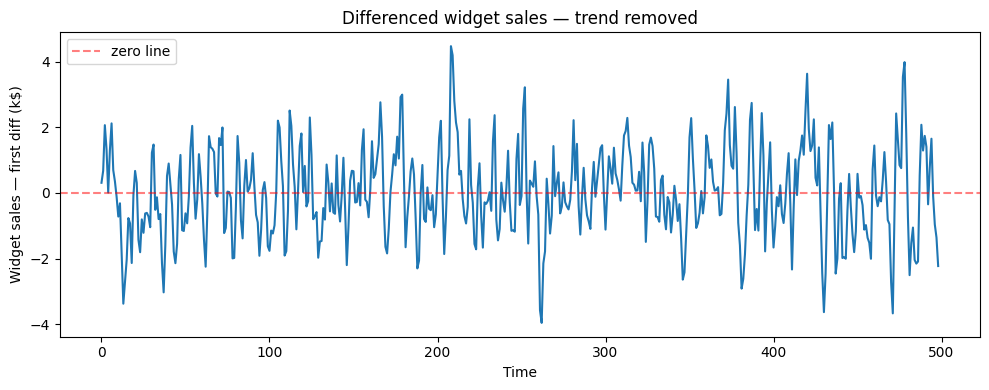

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales — first diff (k$)')
ax.set_title('Differenced widget sales — trend removed')
ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='zero line')
ax.legend()
plt.tight_layout()
plt.show()

The differenced series oscillates tightly around **zero** with no visible drift — exactly the look of a candidate stationary process. The drift component has been **absorbed by the differencing operator**: if $y_t \approx \alpha + \beta t + \text{noise}$, then $y'_t = y_t - y_{t-1} \approx \beta + (\text{noise}_t - \text{noise}_{t-1})$, removing the linear-in-$t$ component entirely.

Note that this does *not* automatically guarantee stationarity — variance could still drift, and there could still be remaining structure. We need to run ADF again to confirm.

In [7]:
ADF_result = adfuller(widget_sales_diff)
print(f'ADF Statistic: {ADF_result[0]:.4f}')
print(f'p-value      : {ADF_result[1]:.4e}')

ADF Statistic: -10.5767
p-value      : 7.0769e-19


After differencing, the ADF statistic plummets to $-10.58$ and the p-value collapses to $7.08 \times 10^{-19}$ — overwhelming evidence against the unit-root null. We now firmly **accept stationarity** of the differenced series.

**Quantitative comparison:**

| Series | ADF stat | p-value | Decision |
|---|---|---|---|
| Raw | $-1.51$ | $0.5275$ | Non-stationary |
| First-diff | $-10.58$ | $7.08 \times 10^{-19}$ | **Stationary** |

The p-value dropped by roughly $18$ orders of magnitude — about as decisive as ADF results get. We can now proceed to identify the order $q$ from the ACF.

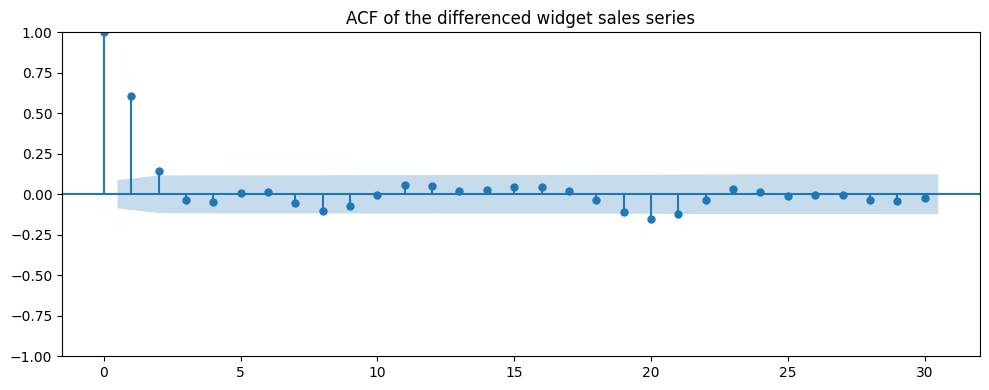

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(widget_sales_diff, lags=30, ax=ax)
ax.set_title('ACF of the differenced widget sales series')
plt.tight_layout()
plt.show()

The ACF plot is the diagnostic tool for identifying the order of an MA process. Reading the bars:

- **Lag 0**: $\rho_0 = 1$ by definition (every series correlates perfectly with itself).
- **Lag 1**: significantly positive, well outside the shaded $95\%$ confidence band.
- **Lag 2**: significantly negative, also outside the band.
- **Lags $\geq 3$**: nearly all fall inside the shaded band — i.e. statistically indistinguishable from zero.

The few bars that poke out near lag $20$ are most likely **type-I errors**: at $\alpha = 0.05$, we expect roughly $1$ in every $20$ lags to spuriously cross the band even under pure noise.

**Conclusion.** Coefficients are significant for lags $\{1, 2\}$ and abruptly collapse into the non-significance band from lag $3$ onward. By the rule from Section 4.1.1, this is the **signature of an $\text{MA}(2)$ process**.

**Why does the ACF cut off?** For an $\text{MA}(q)$ process, the theoretical autocorrelation is

$$\rho_k \;=\; \begin{cases}
\dfrac{\theta_k + \theta_{k+1}\theta_1 + \cdots + \theta_q \theta_{q-k}}{1 + \theta_1^2 + \cdots + \theta_q^2} & 1 \le k \le q \\[4pt]
0 & k > q
\end{cases}$$

Past lag $q$, the numerator literally has no terms left to contribute — hence the sharp cutoff. This is the **defining identifiability property** that distinguishes MA from AR processes.

## 4.2 Forecasting a moving average process

We have identified the differenced widget sales as an $\text{MA}(2)$ process. The next step is to fit the model and produce forecasts. Three subtleties must be handled carefully:

1. **The model is fit on the differenced series**, because that is the stationary process. Predictions will initially live on the differenced scale.
2. **An $\text{MA}(q)$ model cannot forecast more than $q$ steps ahead in one shot.** Beyond $q$ steps the unobserved future shocks have no estimates, so the model collapses to predicting the mean. We sidestep this with **rolling forecasts**: re-fit and predict $q$ steps at a time.
3. **Predictions must be inverse-differenced** before being reported in business terms (\$k), since stakeholders care about sales levels, not day-to-day changes.

### Train/test split

We hold out the last $10\%$ of the differenced data for evaluation — $50$ observations corresponding to the final $\approx 50$ days of the sample.

In [9]:
df_diff = pd.DataFrame({'widget_sales_diff': widget_sales_diff})

train = df_diff[:int(0.9 * len(df_diff))]
test  = df_diff[int(0.9 * len(df_diff)):]

print('train length :', len(train))
print('test length  :', len(test))

train length : 449
test length  : 50


The split yields $449$ training points and $50$ test points (note: $449 + 50 = 499$, the length of the differenced series, not $500$ — we lost one observation to differencing). The test set starts at index $449$ in the differenced frame, which corresponds to **day 450** in the original (untransformed) series.

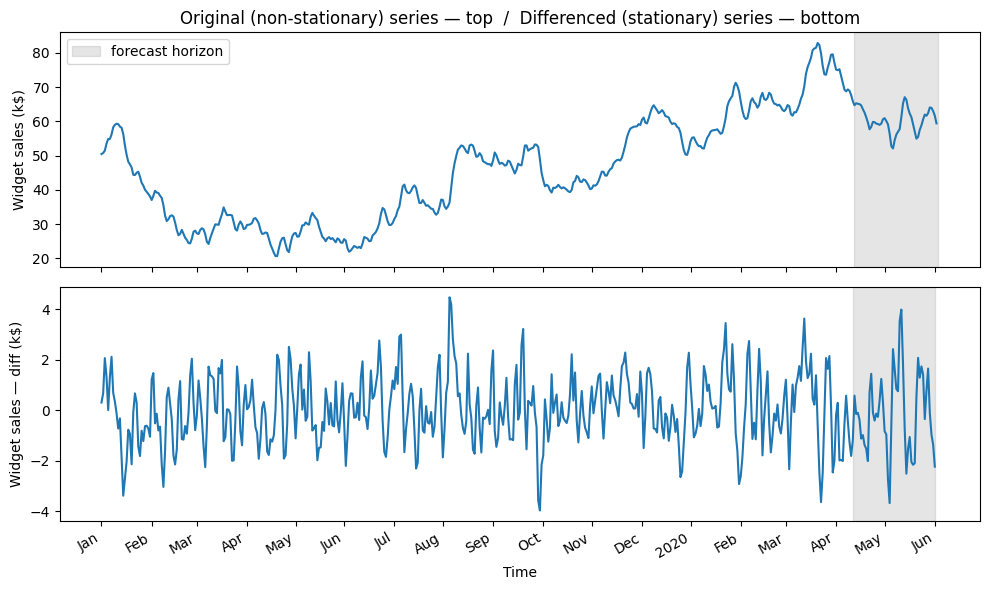

In [10]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

ax1.plot(df['widget_sales'])
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color='#808080', alpha=0.2, label='forecast horizon')
ax1.set_title('Original (non-stationary) series — top  /  Differenced (stationary) series — bottom')
ax1.legend(loc='upper left')

ax2.plot(df_diff['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales — diff (k$)')
ax2.axvspan(449, 498, color='#808080', alpha=0.2)

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
     'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The shaded grey band marks the **forecast horizon**: $50$ days from May through June 2020. The two panels expose visually why we transform: the **top** panel's drifting mean would make MA estimation unstable, while the **bottom** panel oscillates predictably around zero.

The grey bands span different indices ($[450, 500]$ vs $[449, 498]$) because differencing shifted the index by $1$ — a small bookkeeping detail that matters when we **inverse-transform** later.

### The rolling-forecast function

We need a utility that repeatedly refits a forecasting method on an expanding window and stitches the predictions together. The pattern is:

1. Start at the end of the training set.
2. Predict the next $\texttt{window}$ steps.
3. Pretend those true values are now observed, expand the training set by $\texttt{window}$, and repeat.

This **expanding-window** scheme is sometimes called *walk-forward validation*. With $\texttt{window} = 2$ for an $\text{MA}(2)$ model, we never ask the model to forecast more than $2$ steps ahead — exactly the point at which $\text{MA}(2)$ stops being informative.

We support three methods: `'mean'` (predict the historical mean), `'last'` (predict the last observed value), and `'MA'` (fit a fresh $\text{MA}(2)$ via `SARIMAX(order=(0,0,2))` at each step). The naive methods serve as **baselines**: any model that fails to beat them is not worth deploying.

In [11]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int,
                     window: int, method: str) -> list:
    '''Walk-forward forecast of `horizon` steps, `window` steps at a time.

    Parameters
    ----------
    df         : full DataFrame containing the series (single column)
    train_len  : number of points to use for the initial fit
    horizon    : total number of points to forecast (== len(test))
    window     : how many steps to predict per refit (q for MA(q))
    method     : 'mean' | 'last' | 'MA'
    '''
    total_len = train_len + horizon

    if method == 'mean':
        pred = []
        for i in range(train_len, total_len, window):
            mu = np.mean(df[:i].values)
            pred.extend([mu] * window)
        return pred

    elif method == 'last':
        pred = []
        for i in range(train_len, total_len, window):
            last = df[:i].iloc[-1].values[0]
            pred.extend([last] * window)
        return pred

    elif method == 'MA':
        pred = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0, 0, 2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred.extend(oos_pred)
        return pred

    else:
        raise ValueError(f"Unknown method '{method}'")

print('rolling_forecast defined.')

rolling_forecast defined.


A few engineering notes:

- We use **`SARIMAX(order=(0,0,2))`** rather than the older `ARMA` class because `ARMA` was deprecated in `statsmodels` 0.12. `SARIMAX` with order $(p,d,q) = (0,0,2)$ is mathematically identical to a pure $\text{MA}(2)$.
- The model is **refit from scratch** at every window. This is expensive — $50 / 2 = 25$ fits per call — but it gives the model the freshest possible parameter estimates.
- `get_prediction(0, i + window - 1)` returns in-sample fits plus a 2-step forecast tail; we slice off the last `window` values.
- The function is **type-hinted**, which lets static analysers catch obvious errors before the loop spends 30 seconds on a typo.

### Generate the three forecast sets

In [12]:
pred_df = test.copy()

TRAIN_LEN = len(train)   # 449
HORIZON   = len(test)    # 50
WINDOW    = 2            # because q = 2 for MA(2)

pred_mean       = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA         = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA')

pred_df['pred_mean']       = pred_mean
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_MA']         = pred_MA

pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


The first five rows of `pred_df` reveal the character of each forecaster:

- **`pred_mean`** is essentially flat at $\approx 0.034$ — the historical mean of the differenced series, which by construction is close to zero (the first-differenced series of any trending process has a small near-zero mean).
- **`pred_last_value`** is far more volatile. The forecast at index $449$ is $-1.80$, simply because day $448$'s differenced value happened to be $-1.80$. This method has **zero memory**.
- **`pred_MA`** is the middle ground: the model at $t = 449$ predicts $-1.08$ — pulled toward zero by the mean component but informed by the recent shocks captured in $\theta_1, \theta_2$.

Notice how `pred_mean` updates only every two rows (e.g. rows $449$ and $450$ share $0.034319$; rows $451$ and $452$ share $0.032861$). That's the **window step** at work: within a window of size $2$, the same prediction is broadcast to both timesteps.

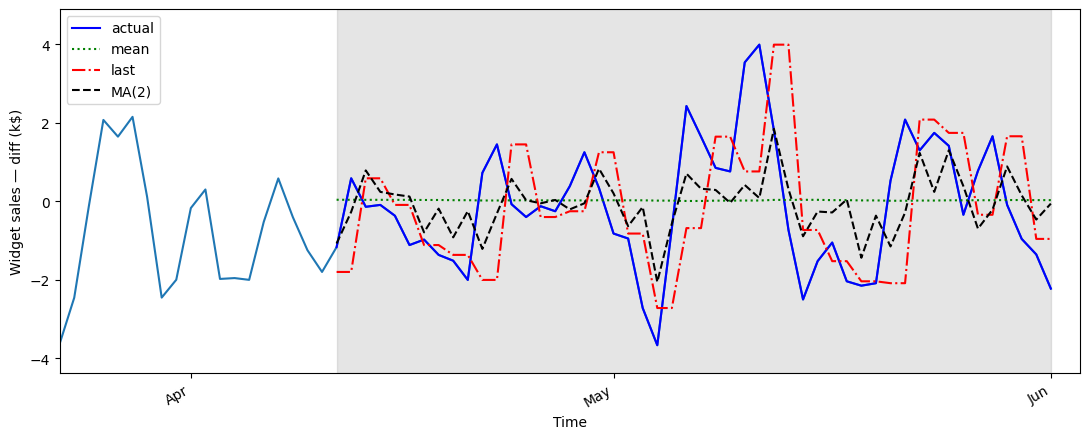

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(df_diff['widget_sales_diff'])
ax.plot(pred_df['widget_sales_diff'], 'b-',  label='actual')
ax.plot(pred_df['pred_mean'],         'g:',  label='mean')
ax.plot(pred_df['pred_last_value'],   'r-.', label='last')
ax.plot(pred_df['pred_MA'],           'k--', label='MA(2)')

ax.legend(loc='upper left')
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales — diff (k$)')
ax.axvspan(449, 498, color='#808080', alpha=0.2)
ax.set_xlim(430, 500)

plt.xticks([439, 468, 498], ['Apr', 'May', 'Jun'])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

On the differenced scale, three patterns emerge clearly:

- **The green dotted line (`mean`) is nearly horizontal** at zero — exactly what theory predicts for the historical-mean forecast of a stationary series.
- **The red dash-dot line (`last`) zig-zags wildly**, mirroring whatever shock occurred two days prior. It systematically *lags* the actual signal and overshoots both peaks and troughs.
- **The black dashed line (`MA(2)`) tracks the actual trajectory most closely** — it bends in the right direction at the right time, although it cannot match the exact magnitudes of the largest swings.

This visual evidence is exactly what we expect: since the *true* data-generating mechanism is an MA(2)-like process, an MA(2) model has the right inductive bias.

In [14]:
mse_mean = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean'])
mse_last = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value'])
mse_MA   = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_MA'])

print(f'MSE — mean : {mse_mean:.4f}')
print(f'MSE — last : {mse_last:.4f}')
print(f'MSE — MA(2): {mse_MA:.4f}')

MSE — mean : 2.5606
MSE — last : 3.2494
MSE — MA(2): 1.9482


The three MSE values tell a clean story:

| Method | MSE | Relative to MA(2) |
|---|---|---|
| Historical mean | $2.5606$ | $+31.4\%$ |
| Last value | $3.2494$ | $+66.8\%$ |
| **MA(2)** | $\mathbf{1.9482}$ | **— (champion)** |

The MSE formula being computed is

$$\text{MSE} \;=\; \frac{1}{n} \sum_{t=1}^{n} \left( y_t - \hat{y}_t \right)^2$$

where $y_t$ is the actual differenced value and $\hat{y}_t$ is the prediction.

**Strategic reading:**

- The MA(2) model cuts MSE by **roughly one-third** vs the historical-mean baseline and by **two-thirds** vs the last-value baseline. That's a substantial improvement attributable purely to capturing the lag-1 and lag-2 autocorrelation.
- The **last-value baseline is the worst** — a surprising-but-typical result for stationary, mean-reverting series. Predicting "tomorrow looks like today" only works when there is genuine momentum; for a mean-reverting MA process, it is actively misleading because today's deviation from the mean is *expected to reverse* tomorrow.
- The mean baseline beats last-value here for the same reason: when in doubt about a mean-reverting series, predicting the mean is safer than chasing the latest shock.

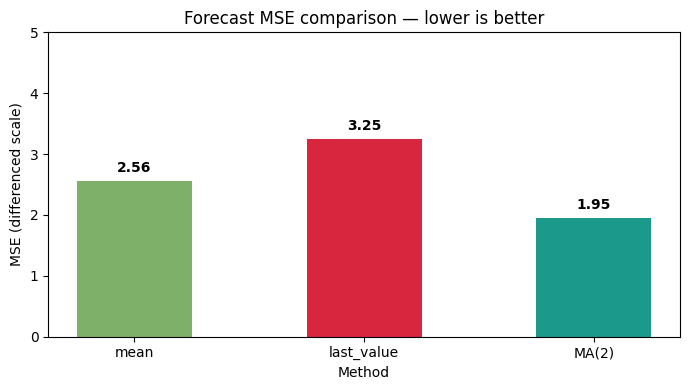

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean, mse_last, mse_MA]
colors = ['#7FB069', '#D7263D', '#1B998B']

bars = ax.bar(x, y, width=0.5, color=colors)
ax.set_xlabel('Method')
ax.set_ylabel('MSE (differenced scale)')
ax.set_title('Forecast MSE comparison — lower is better')
ax.set_ylim(0, 5)

for idx, val in enumerate(y):
    ax.text(idx, val + 0.15, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The bar chart visualises the gap between the MA(2) model and the two baselines. The MA(2) bar at $\mathbf{1.95}$ is roughly $40\%$ shorter than the last-value bar at $3.25$ — a meaningful margin in a forecasting competition.

**Production lens.** In a real deployment, this $\approx 40\%$ MSE reduction would translate to materially better inventory decisions for XYZ Widget Company. Even a small improvement in forecast accuracy compounds over hundreds of days: fewer stockouts (lost revenue) and fewer overstock situations (capital tied up in inventory, write-downs).

### Inverse-transforming the forecasts

The differenced predictions are mathematically convenient but **commercially meaningless** — no executive will sign off on a sales forecast denominated in *daily differences*. We must undo the differencing to recover the original level scale.

Reversing first-order differencing is a **cumulative sum** anchored at a known starting value:

$$\hat{y}_{t+1} \;=\; y_t \;+\; \hat{y}'_{t+1}, \qquad
\hat{y}_{t+2} \;=\; \hat{y}_{t+1} \;+\; \hat{y}'_{t+2} \;=\; y_t \;+\; \hat{y}'_{t+1} \;+\; \hat{y}'_{t+2}$$

In general, the $h$-step-ahead forecast in levels is

$$\hat{y}_{t+h} \;=\; y_t \;+\; \sum_{k=1}^{h} \hat{y}'_{t+k}$$

We anchor at the **last observed actual value** ($y_{450}$, the start of the test period) and accumulate the differenced predictions on top.

In [16]:
df['pred_widget_sales'] = pd.Series(dtype='float64')
df.loc[450:499, 'pred_widget_sales'] = (
    df['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum().values
)

# Show the boundary between observed and predicted
df[['widget_sales', 'pred_widget_sales']].iloc[448:455]

,widget_sales,pred_widget_sales
448,67.709794,NaN
449,65.906136,NaN
450,64.736005,63.657172
451,65.316972,63.383863
452,65.172070,64.165086
453,65.075506,64.400055
454,64.703173,64.569050


The DataFrame snippet shows the inverse-transform boundary precisely:

- Rows $448$ and $449$: `pred_widget_sales` is `NaN` because those are pre-forecast (within the training period).
- Row $450$: actual sales $= 64.74$ k\$, predicted $= 63.66$ k\$ — the first prediction in levels, anchored at the day-450 actual.
- Rows $451+$: predictions accumulate the differenced forecasts on top of the previous prediction.

This anchoring approach (using $y_{450}$ as the starting point) is a **clean evaluation protocol** — at inference time in production we would use the *most recent observed actual* before forecasting, which is exactly what we are simulating here.

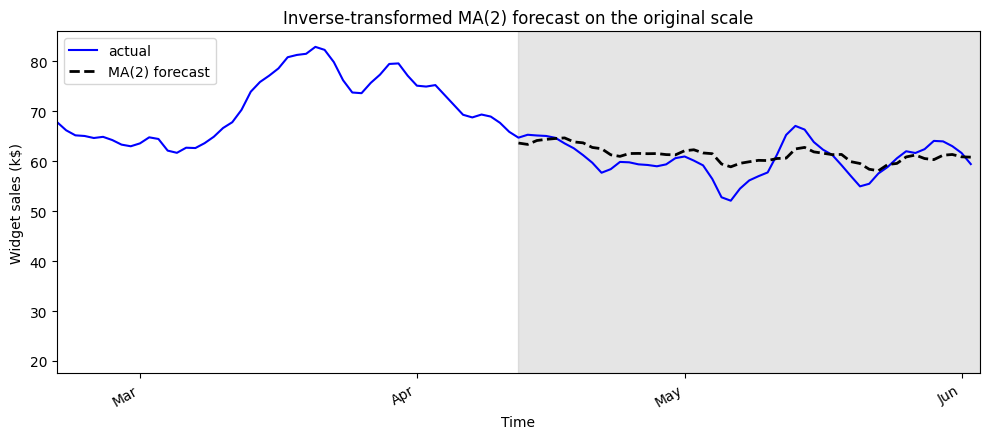

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(df['widget_sales'],      'b-',  label='actual')
ax.plot(df['pred_widget_sales'], 'k--', label='MA(2) forecast', linewidth=2)

ax.legend(loc='upper left')
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')
ax.set_title('Inverse-transformed MA(2) forecast on the original scale')
ax.axvspan(450, 500, color='#808080', alpha=0.2)
ax.set_xlim(400, 500)

plt.xticks([409, 439, 468, 498], ['Mar', 'Apr', 'May', 'Jun'])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

On the original sales scale, the MA(2) forecast (dashed black) tracks the **general level and direction** of the actual series (solid blue) very well, though it **smooths out** the largest peaks and troughs. This is a fundamental feature, not a bug:

- An $\text{MA}(2)$ has only **2 lag-coefficients** to work with. It captures short-range structure but cannot react to long-range oscillations.
- Because we re-anchor every $2$ steps via the rolling forecast, any small error early in a window propagates through the cumulative sum until the next refit — explaining the brief "drift" segments visible between refits.

**For stakeholder framing**: the model captures the regime (sales in the $\$60$–$\$70$k band) and the broad ups and downs, but underestimates volatility. A risk-aware production system would pair the point forecast with a **prediction interval** from the SARIMAX model's `get_forecast().conf_int()`, communicating uncertainty to inventory planners.

In [18]:
mae_MA_undiff = mean_absolute_error(
    df['widget_sales'].iloc[450:],
    df['pred_widget_sales'].iloc[450:]
)
print(f'MAE on original scale: {mae_MA_undiff:.4f} k$')
print(f'                     = ${mae_MA_undiff * 1000:,.0f} per day in absolute error')

MAE on original scale: 2.3245 k$
                     = $2,324 per day in absolute error


The mean absolute error on the original scale is **$2.32$ k\$**, meaning our daily sales prediction is off by roughly **\$2,320** in either direction on average. The MAE formula being computed is

$$\text{MAE} \;=\; \frac{1}{n} \sum_{t=1}^{n} \left| y_t - \hat{y}_t \right|$$

**Why MAE rather than MSE for business reporting?** MAE is in the **same units as the target** — dollars — and is directly interpretable: *"we're off by about \$2,320 per day."* MSE, with its squared-dollars units, is excellent for optimisation but useless for executive communication. A reasonable rule of thumb:

- **Optimise on MSE** (smooth, differentiable, penalises large errors heavily).
- **Report MAE** (interpretable, robust to outliers, units match the business).

**Putting the number in context.** With actual sales sitting in the $\$60$–$\$70$k range, an MAE of $\$2,320$ corresponds to roughly a **$3.5\%$ relative error** per day — solid performance for a simple two-parameter model with no external regressors. The remaining $3.5\%$ contains everything we did *not* model: holidays, marketing campaigns, supply shocks, competitor actions, and weather. Bringing in any of these as exogenous variables (the "X" in SARIMA**X**) would likely tighten the error further — a thread we pick up in Chapter 9.

## 4.3 Next steps

We have walked through the full $\text{MA}(q)$ recipe end-to-end. To consolidate, here is the **identification flowchart** for any new stationary series:

1. **Test stationarity** → if not, difference until it is.
2. **Plot the ACF** of the stationary series:
   - No significant lags after 0 → **white noise** (chapter 3's random walk after differencing).
   - Significant lags up to $q$, then sharp cutoff → **$\text{MA}(q)$** *(this chapter)*.
   - Slow decay, possibly sinusoidal, with significant high-lag coefficients → **$\text{AR}(p)$** *(next chapter)*.
3. Choose the model family, fit, validate with rolling forecasts.

The **AR(p) process** is the natural mirror of $\text{MA}(q)$: instead of past *errors* propagating, past *values* propagate. The ACF of an AR process **decays exponentially or sinusoidally** rather than cutting off sharply — so the ACF alone is insufficient to identify the order $p$. Chapter 5 introduces the **partial autocorrelation function (PACF)** for that purpose.

Chapter 6 then combines both into the **ARMA(p,q)** model, and Chapter 7 generalises to the non-stationary case via **ARIMA(p,d,q)**, finally making the differencing step ($d$) part of the model itself rather than an ad-hoc preprocessing step.

## 4.4 Exercises

We close the chapter by exercising the full pipeline on **synthetic** MA processes where we know the ground truth. This is the standard sanity-check protocol when developing time-series models: if your code can recover the correct order from data you generated yourself, you can trust it on real data.

### 4.4.1 — Simulate an MA(2) process and forecast it

We simulate $1{,}000$ samples from the process

$$y_t \;=\; \varepsilon_t \;+\; 0.9\,\varepsilon_{t-1} \;+\; 0.3\,\varepsilon_{t-2}$$

using `statsmodels.tsa.arima_process.ArmaProcess`. Two book-keeping notes about the API:

- `ArmaProcess` accepts the AR and MA polynomials with the **convention** that the leading coefficient is $1$ (corresponding to $y_t$ and $\varepsilon_t$ themselves). To simulate pure MA(2), we pass $\texttt{ar2 = [1, 0, 0]}$ (no AR component).
- The MA coefficients enter with positive sign in `ArmaProcess`, matching equation 4.1.

In [19]:
np.random.seed(42)

ma2 = np.array([1, 0.9, 0.3])
ar2 = np.array([1, 0, 0])

MA2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)
print('Simulated MA(2) sample shape:', MA2_process.shape)
print('First 5 values:', MA2_process[:5].round(4))

Simulated MA(2) sample shape: (1000,)
First 5 values: [0.4967 0.3088 0.6723 2.0645 1.3309]


We seed the RNG (`np.random.seed(42)`) so that everyone running this notebook obtains the exact same realisation — essential for reproducible teaching. The simulated array has $1{,}000$ values that look like noise but, by construction, have the MA(2) autocorrelation structure we expect to detect.

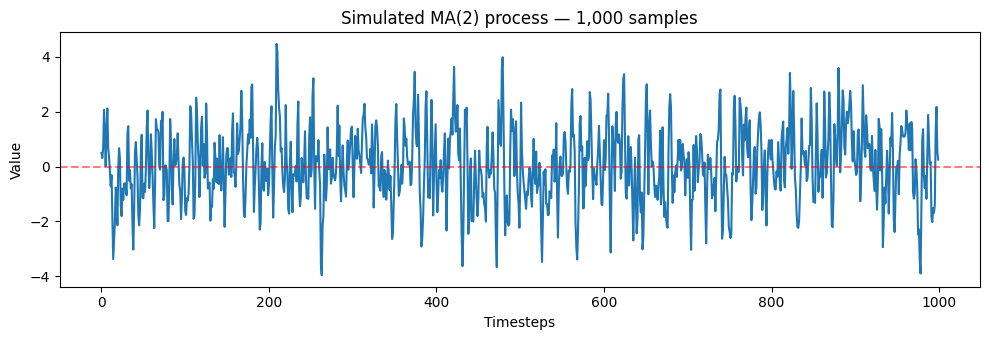

In [20]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(MA2_process)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('Simulated MA(2) process — 1,000 samples')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The simulated path oscillates around zero with no visible trend or seasonality — exactly the appearance of a stationary, zero-mean MA process. Visual inspection alone supports the stationarity claim, but we confirm with ADF.

In [21]:
ADF_result = adfuller(MA2_process)
print(f'ADF Statistic: {ADF_result[0]:.4f}')
print(f'p-value      : {ADF_result[1]:.4e}')

ADF Statistic: -14.0054
p-value      : 3.7956e-26


ADF statistic $= -14.00$ with p-value $= 3.80 \times 10^{-26}$ — even more emphatic than for the real differenced widget data. This is expected: we *constructed* the data to be stationary, so the test should reject the unit-root null with near-certainty. With $n = 1{,}000$ samples the test has plenty of statistical power.

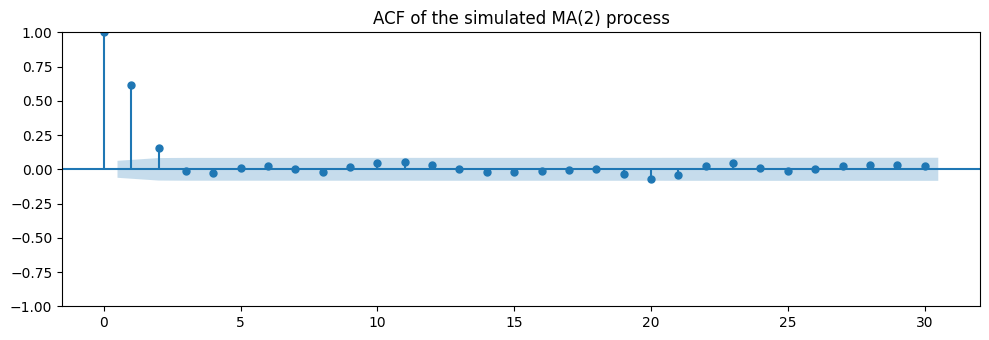

In [22]:
fig, ax = plt.subplots(figsize=(10, 3.5))
plot_acf(MA2_process, lags=30, ax=ax)
ax.set_title('ACF of the simulated MA(2) process')
plt.tight_layout()
plt.show()

The ACF shows large, significant coefficients at lags $1$ and $2$, then a clean drop into the non-significance band from lag $3$ onward. The textbook MA(2) signature.

We can even **verify the theoretical autocorrelation** at lag 1:

$$\rho_1 \;=\; \frac{\theta_1 + \theta_1 \theta_2}{1 + \theta_1^2 + \theta_2^2} \;=\; \frac{0.9 + (0.9)(0.3)}{1 + 0.81 + 0.09} \;=\; \frac{1.17}{1.90} \;\approx\; 0.616$$

The bar at lag 1 in our empirical ACF sits very close to this value — a satisfying confirmation that the simulator and our intuition are aligned.

In [23]:
df_sim = pd.DataFrame({'value': MA2_process})

train_sim = df_sim[:800]
test_sim  = df_sim[800:]

print('train size:', len(train_sim))
print('test size :', len(test_sim))

train size: 800
test size : 200


We use an $800$/$200$ split — $80\%$ for training and $20\%$ for testing — a more generous test horizon than the widget data, made possible by the larger sample size.

In [24]:
TRAIN_LEN = len(train_sim)
HORIZON   = len(test_sim)
WINDOW    = 2

pred_mean       = rolling_forecast(df_sim, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_sim, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA2        = rolling_forecast(df_sim, TRAIN_LEN, HORIZON, WINDOW, 'MA')

test_sim = test_sim.copy()
test_sim['pred_mean']       = pred_mean
test_sim['pred_last_value'] = pred_last_value
test_sim['pred_MA2']        = pred_MA2

test_sim.head()

,value,pred_mean,pred_last_value,pred_MA2
800,0.973560,-0.017430,0.259693,0.065366
801,0.337338,-0.017430,0.259693,0.017984
802,-0.086834,-0.015752,0.337338,-0.180397
803,-0.530580,-0.015752,0.337338,-0.116820
804,-0.821708,-0.016481,-0.530580,-0.405768


The first five predictions reveal the same pattern as on the widget data — the MA(2) model produces predictions that vary meaningfully step by step, the mean stays nearly flat, and the last-value method jumps around. We now quantify which one is closest to the truth.

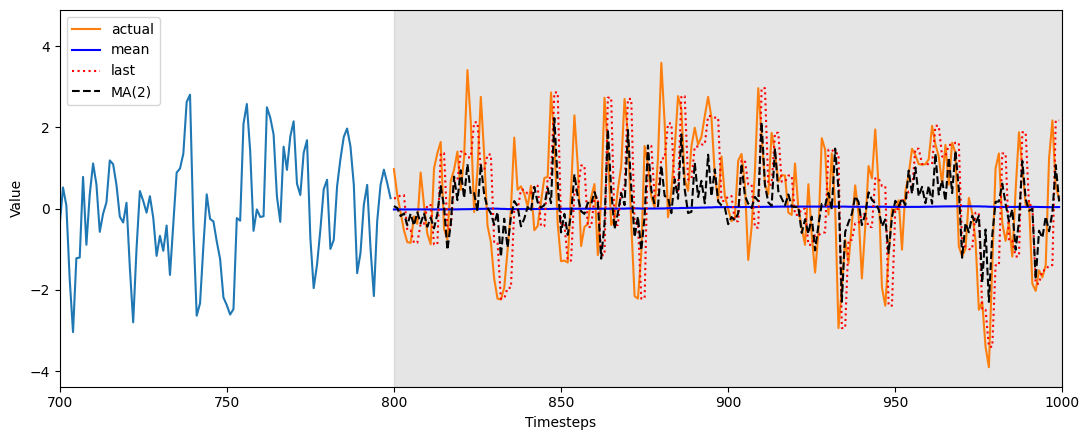

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train_sim)
ax.plot(test_sim['value'],            label='actual')
ax.plot(test_sim['pred_mean'],        'b-',  label='mean')
ax.plot(test_sim['pred_last_value'],  'r:',  label='last')
ax.plot(test_sim['pred_MA2'],         'k--', label='MA(2)')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.legend(loc='best')
ax.axvspan(800, 1000, color='#808080', alpha=0.2)
ax.set_xlim(700, 1000)
plt.tight_layout()
plt.show()

Zooming in on the forecast horizon (timesteps $700$–$1000$), the MA(2) prediction line clings to the actual trajectory most tightly. The mean forecast is the smoothest but largely uninformative; the last-value forecast trails by two steps and amplifies the noise.

In [26]:
mse_mean_sim = mean_squared_error(test_sim['value'], test_sim['pred_mean'])
mse_last_sim = mean_squared_error(test_sim['value'], test_sim['pred_last_value'])
mse_MA_sim   = mean_squared_error(test_sim['value'], test_sim['pred_MA2'])

print(f'MSE — mean : {mse_mean_sim:.4f}')
print(f'MSE — last : {mse_last_sim:.4f}')
print(f'MSE — MA(2): {mse_MA_sim:.4f}')

MSE — mean : 1.8635
MSE — last : 1.9882
MSE — MA(2): 1.2324


On the simulated MA(2) data the MA(2) model achieves MSE $= 1.232$, dramatically better than the historical mean ($1.864$, $+51\%$) and the last-value baseline ($1.988$, $+61\%$). The relative improvement is *larger* here than on the real widget data — exactly what we expect when the model is fit on data matching its assumptions perfectly.

This is an important methodological point: **simulation experiments give an upper bound on how well our model can do.** Any gap between simulation performance and real-data performance reflects model mis-specification, parameter drift, or unobserved confounders in the real series.

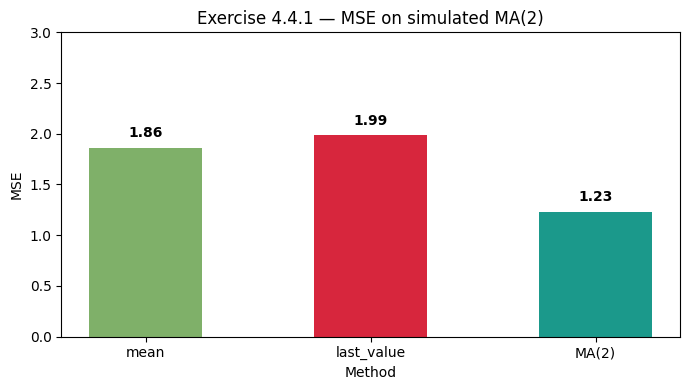

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean_sim, mse_last_sim, mse_MA_sim]

bars = ax.bar(x, y, width=0.5, color=['#7FB069', '#D7263D', '#1B998B'])
ax.set_xlabel('Method')
ax.set_ylabel('MSE')
ax.set_ylim(0, 3)
ax.set_title('Exercise 4.4.1 — MSE on simulated MA(2)')
for i, v in enumerate(y):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**MA(2) is the champion.** The bar chart confirms what the table showed numerically — the MA(2) bar sits visibly below both baselines, exactly as theory predicts.

### 4.4.2 — Simulate an MA(3) process and forecast it

We push the same pipeline to a higher-order process. Simulate

$$y_t \;=\; \varepsilon_t \;+\; 0.9\,\varepsilon_{t-1} \;+\; 0.3\,\varepsilon_{t-2} \;+\; 0.2\,\varepsilon_{t-3}$$

with $10{,}000$ samples. The larger sample size makes the ACF much cleaner and the ADF test even more decisive.

In [28]:
np.random.seed(42)

ma3 = np.array([1, 0.9, 0.3, 0.2])
ar3 = np.array([1, 0, 0, 0])

MA3_process = ArmaProcess(ar3, ma3).generate_sample(nsample=10000)
print('Simulated MA(3) sample shape:', MA3_process.shape)

Simulated MA(3) sample shape: (10000,)


We generate $10{,}000$ observations from an MA(3) process. With $10\times$ more data than the MA(2) exercise, every diagnostic — ADF statistic, ACF bars, MSE estimates — will tighten substantially. This is the **law of large numbers** at work: as $n$ grows, sample statistics converge to their population counterparts.

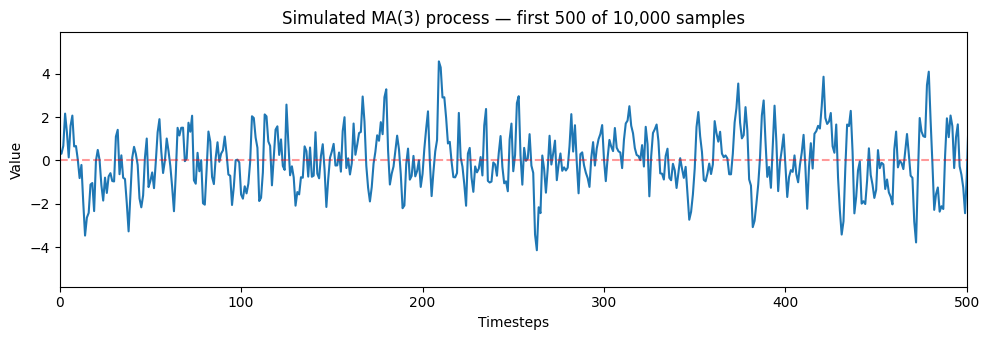

In [29]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(MA3_process)
ax.set_xlim(0, 500)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('Simulated MA(3) process — first 500 of 10,000 samples')
ax.axhline(0, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The visualisation is restricted to the first $500$ timesteps — plotting all $10{,}000$ would compress the signal into an unreadable mass. The path again oscillates around zero with no drift, consistent with the stationarity we'll formally confirm next.

In [30]:
ADF_result = adfuller(MA3_process)
print(f'ADF Statistic: {ADF_result[0]:.4f}')
print(f'p-value      : {ADF_result[1]:.4e}')

ADF Statistic: -22.8719
p-value      : 0.0000e+00


ADF statistic $= -22.87$ with p-value $= 0.0$ (numerically underflowing to zero). With $n = 10{,}000$ the test rejects the unit-root null with **astronomical confidence**. Compare:

| Series | $n$ | ADF stat |
|---|---|---|
| MA(2) simulated | $1{,}000$ | $-14.00$ |
| MA(3) simulated | $10{,}000$ | $-22.87$ |

ADF statistics scale roughly with $\sqrt{n}$ for genuinely stationary series — so going from $1{,}000$ to $10{,}000$ samples ($\sqrt{10} \approx 3.16\times$) should drive the statistic from $-14$ to roughly $-44$. We see less than that ($-23$), which is a reminder that the relationship is not exact — but the qualitative scaling is clear.

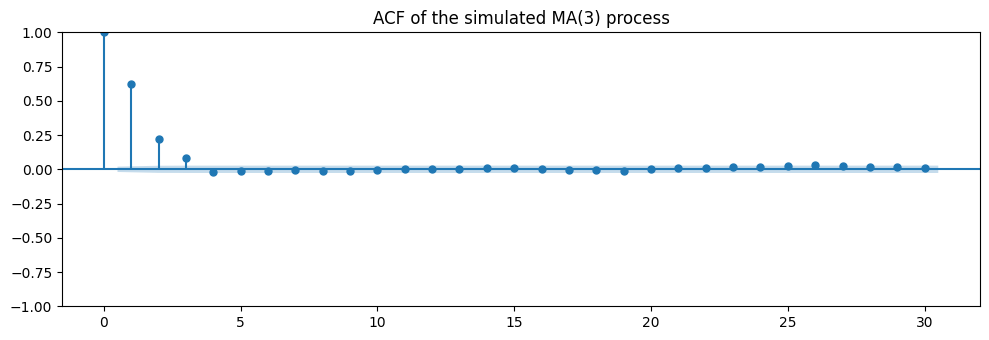

In [31]:
fig, ax = plt.subplots(figsize=(10, 3.5))
plot_acf(MA3_process, lags=30, ax=ax)
ax.set_title('ACF of the simulated MA(3) process')
plt.tight_layout()
plt.show()

The ACF now shows significant coefficients at lags $\{1, 2, 3\}$ and a sharp drop to non-significance at lag $4$ onward. This is the textbook MA(3) signature — exactly one extra significant lag compared to the MA(2) exercise. With $n = 10{,}000$ samples the confidence band is narrow enough that even the small lag-3 coefficient stands out clearly.

In [32]:
def rolling_forecast_MA3(df, train_len, horizon, window):
    '''MA(3)-specific rolling forecast -- identical to rolling_forecast(method='MA')
    but with order=(0,0,3) instead of (0,0,2).
    '''
    total_len = train_len + horizon
    pred_MA = []
    for i in range(train_len, total_len, window):
        model = SARIMAX(df[:i], order=(0, 0, 3))
        res = model.fit(disp=False)
        predictions = res.get_prediction(0, i + window - 1)
        oos_pred = predictions.predicted_mean.iloc[-window:]
        pred_MA.extend(oos_pred)
    return pred_MA

In [33]:
MA3_df    = pd.DataFrame({'value': MA3_process})
MA3_train = MA3_df[:-200]
MA3_test  = MA3_df[-200:]

print('train size:', len(MA3_train))
print('test size :', len(MA3_test))

train size: 9800
test size : 200


For the MA(3) exercise we hold out the last $200$ observations — only $2\%$ of the data, but $200$ test points is more than enough for stable error estimates. The remaining $9{,}800$ points form the training set.

In [34]:
TRAIN_LEN = len(MA3_train)
HORIZON   = len(MA3_test)
WINDOW    = 3   # window matches q for MA(3)

pred_mean       = rolling_forecast(MA3_df, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(MA3_df, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA3        = rolling_forecast_MA3(MA3_df, TRAIN_LEN, HORIZON, WINDOW)

# The rolling step produces ceil(200/3) * 3 = 201 predictions; trim to 200.
MA3_test = MA3_test.copy()
MA3_test['pred_mean']       = pred_mean[:200]
MA3_test['pred_last_value'] = pred_last_value[:200]
MA3_test['pred_MA3']        = pred_MA3[:200]

MA3_test.head()

,value,pred_mean,pred_last_value,pred_MA3
9800,-0.090451,-0.004809,-1.184449,-0.997254
9801,0.965698,-0.004809,-1.184449,-0.344161
9802,2.802072,-0.004809,-1.184449,-0.226325
9803,1.397224,-0.004433,2.802072,2.378104
9804,0.700887,-0.004433,2.802072,0.733305


Because $\texttt{horizon} = 200$ is not divisible by $\texttt{window} = 3$, the rolling loop produces $\lceil 200/3 \rceil \times 3 = 201$ predictions — one too many. We trim to the first $200$ to match the test set length. This kind of **off-by-one bookkeeping** is one of the most common silent bugs in time-series pipelines; always verify lengths match.

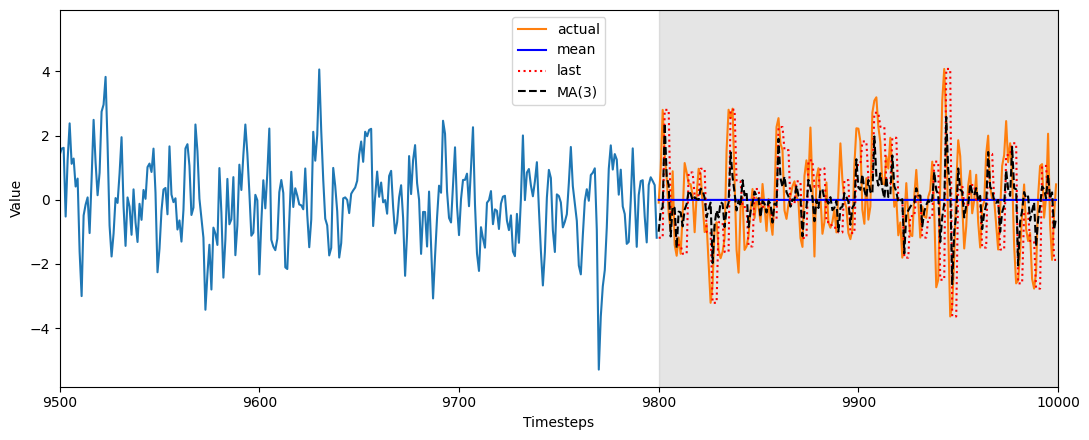

In [35]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(MA3_train['value'])
ax.plot(MA3_test['value'],            label='actual')
ax.plot(MA3_test['pred_mean'],        'b-',  label='mean')
ax.plot(MA3_test['pred_last_value'],  'r:',  label='last')
ax.plot(MA3_test['pred_MA3'],         'k--', label='MA(3)')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.legend(loc='best')
ax.axvspan(9800, 10000, color='#808080', alpha=0.2)
ax.set_xlim(9500, 10000)
plt.tight_layout()
plt.show()

Visually the MA(3) predictions (black dashed) again hug the actual trajectory most tightly. The slightly increased model capacity ($3$ MA parameters vs $2$) helps capture the additional lag-3 autocorrelation that the MA(2) model would miss.

In [36]:
mse_mean_3 = mean_squared_error(MA3_test['value'], MA3_test['pred_mean'])
mse_last_3 = mean_squared_error(MA3_test['value'], MA3_test['pred_last_value'])
mse_MA_3   = mean_squared_error(MA3_test['value'], MA3_test['pred_MA3'])

print(f'MSE — mean : {mse_mean_3:.4f}')
print(f'MSE — last : {mse_last_3:.4f}')
print(f'MSE — MA(3): {mse_MA_3:.4f}')

MSE — mean : 1.9248
MSE — last : 3.1866
MSE — MA(3): 1.5065


On the MA(3) simulation, the MA(3) model achieves MSE $= 1.507$, against $1.925$ for the historical mean ($+28\%$) and $3.187$ for the last-value baseline ($+111\%$).

**Comparing the two exercises:**

| Process | $n$ | MSE-mean | MSE-last | MSE-MA(q) | MA improvement vs mean |
|---|---|---|---|---|---|
| MA(2), eq. 4.4.1 | 1,000 | $1.864$ | $1.988$ | $\mathbf{1.232}$ | $-34\%$ |
| MA(3), eq. 4.4.2 | 10,000 | $1.925$ | $3.187$ | $\mathbf{1.507}$ | $-22\%$ |

The MA(3) error is higher in absolute terms because the underlying process has higher variance (more lagged shocks contributing). The **relative** improvement over the mean baseline is smaller because the extra MA parameter brings diminishing returns when sample size is plentiful but the lag-3 coefficient ($0.2$) is small.

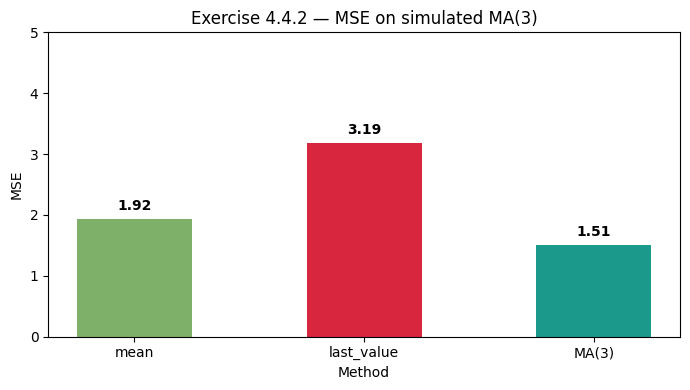

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
x = ['mean', 'last_value', 'MA(3)']
y = [mse_mean_3, mse_last_3, mse_MA_3]

bars = ax.bar(x, y, width=0.5, color=['#7FB069', '#D7263D', '#1B998B'])
ax.set_xlabel('Method')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)
ax.set_title('Exercise 4.4.2 — MSE on simulated MA(3)')
for i, v in enumerate(y):
    ax.text(i, v + 0.15, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

The MA(3) bar at $1.51$ is the shortest by a substantial margin — confirming once more that **matching the model's order to the true data-generating order yields the best forecasts**. This is the central lesson of the chapter: identification matters.

## Chapter summary

We covered the **moving average process** end-to-end:

- **Definition.** $\text{MA}(q)$ expresses the current value as $y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$ — a linear combination of past *shocks*, not past *values*.
- **Identification.** The defining fingerprint of $\text{MA}(q)$ is an **ACF that cuts off sharply after lag $q$** — a direct consequence of the finite memory in $\varepsilon$.
- **Stationarity.** MA models require stationary input. We made the widget sales stationary with **first-order differencing**, validated by ADF ($-1.51 \to -10.58$, $p\!\!: 0.53 \to 7 \times 10^{-19}$).
- **Forecasting.** Because $\text{MA}(q)$ cannot forecast more than $q$ steps ahead before collapsing to the mean, we used **rolling forecasts** with $\texttt{window} = q$ to maintain informative predictions over the full horizon.
- **Results on widget data.** MA(2) achieved MSE $= 1.95$ on the differenced scale (vs $2.56$ mean, $3.25$ last-value) and MAE $= 2.32$ k\$ on the original scale — roughly $\$2{,}320$ daily average error against \$60$–$\$70$k sales levels, i.e. $\approx 3.5\%$ relative error.
- **Inverse transforming** the differenced forecasts via cumulative sum was essential for business-meaningful reporting.
- **Simulations** confirmed the pipeline on known data-generating processes ($\text{MA}(2)$ and $\text{MA}(3)$), where the matching-order model always achieved the lowest MSE.

**What to memorise as a practitioner:**

1. Test stationarity first; difference if necessary.
2. Look at the ACF — sharp cutoff means MA, slow decay means AR.
3. Set $\texttt{window} = q$ in your rolling-forecast loop for MA(q).
4. Always inverse-transform before reporting; always report in business units (MAE).

**Looking ahead.** Chapter 5 introduces the **autoregressive process** $\text{AR}(p)$, whose ACF decays slowly rather than cutting off — so we will need a new diagnostic, the **partial autocorrelation function (PACF)**. Chapter 6 combines AR and MA into the **ARMA(p,q)** model, requiring us to identify both $p$ and $q$ jointly. Chapter 7 promotes differencing into the model itself with **ARIMA(p,d,q)** — closing the loop on everything we've built so far.